# ESS Battery Health - ESS 배터리 수명 모델 개발 및 평가

변경된 `01_EDA.ipynb`의 설계 전략을 이어받아 **회귀**를 수행한다. 초기 100사이클로 셀의 총 `cycle_life`를 예측한다. 운영 중 잔여수명(RUL)을 예측하는 과제는 아니다.


| 단계 | 이번 실습에서 수행할 내용 |
|---|---|
| 학습·모델 선택 | Batch1의 정책 그룹 Hold-out을 먼저 분리하고, 개발 부분의 5-fold GroupKFold에서 세 후보 비교 |
| 내부 검증 | 선택한 설정을 고정한 후 Batch1 Hold-out 평가 |
| 최종 학습 | 같은 설정으로 Batch1 전체 재학습 |
| 테스트 | Batch2 최종 평가와 Batch3 추가 검증. 결과로 재선택·재튜닝하지 않음 |
| 성능 보고 | CV 평균, Hold-out, Batch2, Batch3와 Gap 및 과제 목표 MAPE 9.1% 비교 |

DAY1의 후보는 LinearRegression, Ridge, 얕은 RandomForestRegressor다. 


## 1. DAY1 설계 적용 및 모델링 데이터 준비

### 1.1 환경과 고정된 실험 설정

이 노트북은 DAY1을 실행하지 않아도 독립적으로 실행할 수 있다.

In [1]:
from pathlib import Path
import importlib.metadata
import json
import platform
import re
import sys

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import exp10
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

NOTEBOOK_VERSION = 'DAY2-v3-rebuilt-from-current-DAY1'
ROOT = Path.cwd()
if not (ROOT / '01_EDA.ipynb').is_file():
    raise FileNotFoundError('작업 폴더 ds-mini-project에서 실행해 주세요.')
RESULTS_DIR = ROOT / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
PAPER_MAPE = 9.1
np.random.seed(SEED)
BATCH_FILES = {
    'Batch 1': ROOT / '2017-05-12_batchdata_updated_struct_errorcorrect.mat',
    'Batch 2': ROOT / '2018-02-20_batchdata_updated_struct_errorcorrect.mat',
    'Batch 3': ROOT / '2018-04-12_batchdata_updated_struct_errorcorrect.mat',
}
FEATURE_SETS = {
    'A_core': ['log10_delta_q_var'],
    'B_charging_conditions': ['log10_delta_q_var', 'c_rate_1', 'switch_soc'],
    'C_charging_time': ['log10_delta_q_var', 'c_rate_1', 'switch_soc', 'chargetime_mean'],
}
ALL_FEATURES = FEATURE_SETS['C_charging_time']
VERSIONS = {name: importlib.metadata.version(name) for name in
            ['numpy', 'pandas', 'scipy', 'matplotlib', 'h5py', 'scikit-learn', 'joblib', 'ipykernel', 'nbformat', 'nbclient']}
for path in BATCH_FILES.values():
    if not path.is_file():
        raise FileNotFoundError(path)
print('노트북 버전:', NOTEBOOK_VERSION)
print('Python 실행 경로:', sys.executable)
print('Python 버전:', platform.python_version())
display(pd.Series(VERSIONS, name='version').to_frame())
display(pd.DataFrame([{'feature_set': name, 'features': ', '.join(columns)}
                      for name, columns in FEATURE_SETS.items()]))


노트북 버전: DAY2-v3-rebuilt-from-current-DAY1
Python 실행 경로: /Users/jjy/ds-mini-project/.venv/bin/python
Python 버전: 3.11.15


,version
numpy,2.4.6
pandas,3.0.6
scipy,1.17.1
matplotlib,3.11.2
h5py,3.16.0
scikit-learn,1.9.1
joblib,1.6.0
ipykernel,7.4.0
nbformat,5.11.1
nbclient,0.11.0


,feature_set,features
0,A_core,log10_delta_q_var
1,B_charging_conditions,"log10_delta_q_var, c_rate_1, switch_soc"
2,C_charging_time,"log10_delta_q_var, c_rate_1, switch_soc, charg..."


### 1.2 원본 데이터 읽기

In [2]:
SUMMARY_FIELDS = ['cycle', 'QDischarge', 'QCharge', 'IR', 'Tmax', 'Tavg', 'Tmin', 'chargetime']

def read_reference(h5, reference):
    return np.asarray(h5[reference][()]).squeeze()

def read_text_reference(h5, reference):
    return ''.join(chr(int(value)) for value in read_reference(h5, reference).reshape(-1) if int(value) != 0)

def load_raw_batch(path, batch_name):
    metadata, raw_inputs = [], {}
    with h5py.File(path, 'r') as h5:
        batch = h5['batch']
        for index in range(batch['cycle_life'].shape[0]):
            cell_id = f'{batch_name.replace(" ", "")}_cell_{index:03d}'
            try:
                life = float(read_reference(h5, batch['cycle_life'][index, 0]))
                policy = read_text_reference(h5, batch['policy_readable'][index, 0])
                summary = h5[batch['summary'][index, 0]]
                # DAY1과 같은 최소 길이. 읽어들이는 측정값은 초기 cycle/chargetime뿐이다.
                n = min(summary[field].size for field in SUMMARY_FIELDS)
                cycle = np.asarray(summary['cycle'][()]).reshape(-1).astype(float)[:n]
                charge_time = np.asarray(summary['chargetime'][()]).reshape(-1).astype(float)[:n]
                initial = cycle <= 100
                n_initial = len(np.unique(cycle[(cycle >= 1) & (cycle <= 100)]))
                curves = h5[batch['cycles'][index, 0]]
                has_qv = curves['Qdlin'].shape[0] >= 100
                raw = {'cycle': cycle[initial], 'chargetime': charge_time[initial]}
                if has_qv:
                    raw.update({
                        'voltage': read_reference(h5, batch['Vdlin'][index, 0]),
                        'q10': read_reference(h5, curves['Qdlin'][9, 0]),
                        'q100': read_reference(h5, curves['Qdlin'][99, 0]),
                    })
                raw_inputs[cell_id] = raw
                metadata.append({'batch': batch_name, 'cell_id': cell_id, 'charging_policy': policy,
                                 'cycle_life': life, 'n_initial_cycles': n_initial, 'has_qv': has_qv})
            except Exception as error:
                raise RuntimeError(f'{batch_name} / {cell_id} 로딩 실패') from error
    return pd.DataFrame(metadata), raw_inputs

batch1_meta, batch1_raw = load_raw_batch(BATCH_FILES['Batch 1'], 'Batch 1')
batch1_eligible = batch1_meta.loc[
    np.isfinite(batch1_meta['cycle_life']) & (batch1_meta['cycle_life'] > 0)
    & (batch1_meta['n_initial_cycles'] == 100) & batch1_meta['has_qv']
].reset_index(drop=True)
print('Batch1 원본 셀:', len(batch1_meta), '/ 학습·검증 가능한 셀:', len(batch1_eligible))
display(batch1_meta.head())


Batch1 원본 셀: 46 / 학습·검증 가능한 셀: 46


,batch,cell_id,charging_policy,cycle_life,n_initial_cycles,has_qv
0,Batch 1,Batch1_cell_000,3.6C(80%)-3.6C,1190.0,100,True
1,Batch 1,Batch1_cell_001,3.6C(80%)-3.6C,1179.0,100,True
2,Batch 1,Batch1_cell_002,3.6C(80%)-3.6C,1177.0,100,True
3,Batch 1,Batch1_cell_003,4C(80%)-4C,1226.0,100,True
4,Batch 1,Batch1_cell_004,4C(80%)-4C,1227.0,100,True


### 1.3 Batch1을 먼저 분할 — 정책 그룹 Hold-out과 CV

하나의 행은 하나의 셀이다. 같은 충전 정책의 셀이 훈련과 검증 양쪽에 들어가지 않도록 **충전 정책을 그룹으로 분할**한다. 단순 셀 Hold-out만으로는 동일 정책의 중복을 막을 수 없다.

정책 그룹의 약 20%를 Hold-out으로 보관하고 나머지 개발 셀에서만 5-fold CV를 한다. 그룹 크기가 달라 셀 비율은 정확히 20%가 아닐 수 있다. 실험 날짜가 있는 운영 시계열 예측이 아니라 초기 관측을 집계한 독립 셀 회귀이므로 여기서는 셀의 시간축을 무작위로 나누지 않는다. 미래 운영 시계열 검증에서는 시간 순서를 지켜야 한다.


문자열 표기가 달라도 같은 수치 조건은 동일 그룹이 되도록 `첫 C-rate|전환 SOC|둘째 C-rate`로 정규화한다. 이 그룹 식별자는 모델 입력이 아니다.

In [3]:
def protocol_group(policy):
    pattern = r'(\d+(?:\.\d+)?)C\((\d+(?:\.\d+)?)%\)-(\d+(?:\.\d+)?)C'
    match = re.search(pattern, str(policy).replace(' ', ''))
    if not match:
        raise ValueError(f'Batch1 충전 정책 해석 실패: {policy}')
    return '|'.join(f'{float(value):g}' for value in match.groups())

# 표기가 달라도 같은 수치 충전 조건은 같은 그룹이다. 그룹은 입력 피처가 아니다.
batch1_eligible['protocol_group'] = batch1_eligible.charging_policy.map(protocol_group)
holdout_splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
development_index, holdout_index = next(holdout_splitter.split(
    batch1_eligible, groups=batch1_eligible['protocol_group']))
development_meta = batch1_eligible.iloc[development_index].reset_index(drop=True)
holdout_meta = batch1_eligible.iloc[holdout_index].reset_index(drop=True)
assert set(development_meta.cell_id).isdisjoint(holdout_meta.cell_id)
assert set(development_meta.protocol_group).isdisjoint(holdout_meta.protocol_group)

group_cv = GroupKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_splits = list(group_cv.split(development_meta, groups=development_meta['protocol_group']))
split_rows = []
for fold, (train_index, valid_index) in enumerate(cv_splits, start=1):
    train_meta = development_meta.iloc[train_index]
    valid_meta = development_meta.iloc[valid_index]
    assert set(train_meta.cell_id).isdisjoint(valid_meta.cell_id)
    assert set(train_meta.protocol_group).isdisjoint(valid_meta.protocol_group)
    split_rows.append({'fold': fold, 'train_cells': len(train_meta), 'valid_cells': len(valid_meta),
                       'train_groups': train_meta.charging_policy.nunique(),
                       'valid_groups': valid_meta.charging_policy.nunique(),
                       'valid_life_min': valid_meta.cycle_life.min(), 'valid_life_max': valid_meta.cycle_life.max()})
print('개발:', len(development_meta), '셀 /', development_meta.charging_policy.nunique(), '정책')
print('Hold-out:', len(holdout_meta), '셀 /', holdout_meta.charging_policy.nunique(), '정책')
display(pd.DataFrame(split_rows))


개발: 35 셀 / 18 정책
Hold-out: 11 셀 / 5 정책


,fold,train_cells,valid_cells,train_groups,valid_groups,valid_life_min,valid_life_max
0,1,28,7,14,4,636.0,1074.0
1,2,27,8,14,4,648.0,1054.0
2,3,27,8,14,4,599.0,1227.0
3,4,29,6,15,3,534.0,906.0
4,5,29,6,15,3,617.0,880.0


### 1.4 DAY1에서 정한 피처 만들기


| 피처 | 계산과 DAY1 연결 |
|---|---|
| log10_delta_q_var | ΔQ(V)=Q100(V)−Q10(V)를 공통 2.0~3.6V, 1000점에 정렬하고 유효 구간의 표본분산(ddof=1)을 log10 변환. 핵심 열화 신호 |
| c_rate_1 | 첫 충전 단계 C-rate. 충전 강도 정보 |
| switch_soc | 첫 단계에서 다음 단계로 전환하는 SOC(%). 충전 조건 정보 |
| chargetime_mean | 초기 Cycle1~100 충전시간의 결측을 제외한 평균. 추가 피처의 효과 확인 |

전압축이 다른 곡선을 인덱스만으로 비교하지 않고 DAY1의 공통 전압축 규칙을 그대로 사용한다. 관측 범위 밖을 예측하지 않는다. 차이 계산 전 두 Qdlin 길이가 맞는지도 검사한다. 분산이 0이면 DAY1과 같이 부동소수 최소 양수로 제한한다.

입력 결측은 뒤의 파이프라인에서 훈련 부분 중앙값으로 대체한다. 결측 수명은 대체하지 않는다. 초기 100사이클·ΔQ 곡선 자체가 없는 셀은 초기수명 예측 대상에서 제외하고 개수를 기록한다.


In [4]:
COMMON_VOLTAGE = np.linspace(2.0, 3.6, 1000)
POLICY_PATTERN = re.compile(r'(\d+(?:\.\d+)?)C\((\d+(?:\.\d+)?)%\)-(\d+(?:\.\d+)?)C')

def align_curve(voltage, values):
    voltage = np.asarray(voltage, dtype=float).reshape(-1)
    values = np.asarray(values, dtype=float).reshape(-1)
    n = min(len(voltage), len(values))
    voltage, values = voltage[:n], values[:n]
    valid = np.isfinite(voltage) & np.isfinite(values)
    voltage, values = voltage[valid], values[valid]
    if len(values) < 10:
        return np.full_like(COMMON_VOLTAGE, np.nan)
    order = np.argsort(voltage)
    voltage, values = voltage[order], values[order]
    voltage, unique_index = np.unique(voltage, return_index=True)
    return np.interp(COMMON_VOLTAGE, voltage, values[unique_index], left=np.nan, right=np.nan)

def make_features(metadata, raw_inputs):
    rows = []
    for item in metadata.to_dict('records'):
        raw = raw_inputs[item['cell_id']]
        log_variance = np.nan
        n_delta = 0
        if item['has_qv']:
            if raw['q100'].shape != raw['q10'].shape:
                raise ValueError(f"{item['cell_id']}: Q100과 Q10 길이가 다릅니다.")
            delta = align_curve(raw['voltage'], raw['q100'] - raw['q10'])
            values = delta[np.isfinite(delta)]
            n_delta = len(values)
            if n_delta >= 10:
                log_variance = np.log10(max(np.var(values, ddof=1), np.finfo(float).tiny))
        match = POLICY_PATTERN.search(str(item['charging_policy']).replace(' ', ''))
        c1, soc, c2 = tuple(map(float, match.groups())) if match else (np.nan, np.nan, np.nan)
        rows.append({**item, 'log10_delta_q_var': log_variance, 'c_rate_1': c1, 'switch_soc': soc,
                     'chargetime_mean': pd.Series(raw['chargetime']).mean(), 'n_delta_points': n_delta})
    return pd.DataFrame(rows).replace([np.inf, -np.inf], np.nan)

development_df = make_features(development_meta, batch1_raw)
holdout_df = make_features(holdout_meta, batch1_raw)
batch1_df = pd.concat([development_df, holdout_df], ignore_index=True).sort_values('cell_id').reset_index(drop=True)
assert (batch1_df.n_delta_points >= 10).all(), 'Batch1에 유효 ΔQ 곡선이 없는 셀이 있습니다.'
assert not batch1_df[ALL_FEATURES].isna().all().any(), '전체 결측 피처를 확인해 주세요.'
quality_rows = []

def quality_summary(metadata, features):
    positive_target = np.isfinite(features.cycle_life) & (features.cycle_life > 0)
    eligible_input = (features.n_initial_cycles == 100) & (features.n_delta_points >= 10)
    return {'batch': metadata.batch.iloc[0], 'raw_cells': len(metadata),
            'missing_target': int(metadata.cycle_life.isna().sum()),
            'nonpositive_target': int((metadata.cycle_life <= 0).sum()),
            'input_ineligible': int((~eligible_input).sum()),
            'scored_cells': int((positive_target & eligible_input).sum()),
            'unlabeled_prediction_cells': int((~positive_target & eligible_input).sum())}

quality_rows.append(quality_summary(batch1_meta, make_features(batch1_meta, batch1_raw)))
display(batch1_df[['cell_id', 'cycle_life'] + ALL_FEATURES].head())
display(batch1_df[ALL_FEATURES].isna().sum().rename('missing_inputs').to_frame())


,cell_id,cycle_life,log10_delta_q_var,c_rate_1,switch_soc,chargetime_mean
0,Batch1_cell_000,1190.0,-5.014398,3.6,80.0,13.250388
1,Batch1_cell_001,1179.0,-5.013692,3.6,80.0,13.240949
2,Batch1_cell_002,1177.0,-4.736606,3.6,80.0,13.245097
3,Batch1_cell_003,1226.0,-4.442330,4.0,80.0,11.932744
4,Batch1_cell_004,1227.0,-4.647432,4.0,80.0,11.932781


,missing_inputs
log10_delta_q_var,0
c_rate_1,0
switch_soc,0
chargetime_mean,0


## 2. 세 후보 모델과 전처리 파이프라인

LinearRegression은 핵심 피처 A로 단순 관계를 확인한다. Ridge는 A/B/C를 비교해 작은 표본과 피처 간 상관에 규제가 도움이 되는지 확인한다. Random Forest는 A/B/C를 비교하되 깊이와 최소 잎 크기를 제한해 비선형성의 추가 효과를 확인한다. 총 7개의 모델·피처 조합이다.

각 훈련 폴드 안에서만 중앙값 대체와 스케일러를 fit한다. 트리에는 스케일러를 쓰지 않는다. `TransformedTargetRegressor`가 log10 수명을 학습하고 예측 시 원래 Cycle 단위로 되돌린다. 로그 역변환 예측은 원래 단위의 조건부 평균과 같다고 보장되지 않으므로 잔차도 확인한다.


DAY1에서 Batch1의 log10_delta_q_var와 수명의 Spearman ρ=-0.871이 확인됐지만 단조 관계가 선형 관계를 보장하지는 않는다. 따라서 LinearRegression으로 단순 관계를 확인한다. Batch1의 독립 셀은 46개이고 c_rate_1과 switch_soc의 ρ=-0.869로 정보 중복이 있어 Ridge 규제를 비교한다. 충전 정책 차이를 첫 C-rate 하나로 모두 설명할 수 없으므로 얕은 Random Forest로 비선형 관계와 상호작용의 추가 효과를 확인한다. 규제나 비선형 모델의 개선을 미리 보장하지 않는다.

In [5]:
def make_estimator(model_name):
    steps = [('imputer', SimpleImputer(strategy='median', keep_empty_features=True))]
    if model_name == 'LinearRegression':
        model = LinearRegression()
    elif model_name == 'Ridge':
        model = Ridge()
    elif model_name == 'RandomForestRegressor':
        model = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=1)
    else:
        raise ValueError(model_name)
    if model_name != 'RandomForestRegressor':
        steps.append(('scaler', StandardScaler()))
    steps.append(('model', model))
    # 기본 제공 함수만 사용하므로 저장 모델을 새 Python 프로세스에서도 불러올 수 있다.
    return TransformedTargetRegressor(regressor=Pipeline(steps), func=np.log10, inverse_func=exp10)

experiments = [{'model': 'LinearRegression', 'feature_set': 'A_core', 'grid': {}}]
for feature_set in FEATURE_SETS:
    experiments.append({'model': 'Ridge', 'feature_set': feature_set,
                        'grid': {'regressor__model__alpha': np.logspace(-3, 3, 7)}})
    experiments.append({'model': 'RandomForestRegressor', 'feature_set': feature_set,
                        'grid': {'regressor__model__max_depth': [2, 3],
                                 'regressor__model__min_samples_leaf': [3, 5]}})
SCORING = {'mape': 'neg_mean_absolute_percentage_error', 'mae': 'neg_mean_absolute_error',
           'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}
display(pd.DataFrame([{'model': item['model'], 'feature_set': item['feature_set'],
                      'parameter_grid': str(item['grid'])} for item in experiments]))


,model,feature_set,parameter_grid
0,LinearRegression,A_core,{}
1,Ridge,A_core,"{'regressor__model__alpha': array([1.e-03, 1.e..."
2,RandomForestRegressor,A_core,"{'regressor__model__max_depth': [2, 3], 'regre..."
3,Ridge,B_charging_conditions,"{'regressor__model__alpha': array([1.e-03, 1.e..."
4,RandomForestRegressor,B_charging_conditions,"{'regressor__model__max_depth': [2, 3], 'regre..."
5,Ridge,C_charging_time,"{'regressor__model__alpha': array([1.e-03, 1.e..."
6,RandomForestRegressor,C_charging_time,"{'regressor__model__max_depth': [2, 3], 'regre..."


## 3. Batch1에서 모델·피처·하이퍼파라미터 선택

모든 후보에 같은 CV 분할을 사용한다. 평균 검증 MAPE가 가장 작은 설정을 선택하며, 정확히 동률이면 더 적은 피처를 우선한다. Hold-out과 Batch2·3의 성능은 이 선택에 사용하지 않는다.

표의 CV 성능은 **각 폴드 검증 오차의 평균**이다. 학습에 사용한 셀에 대한 훈련 오차가 아니다. 여러 후보 중 고른 CV 성능은 선택에 사용됐으므로 다소 낙관적일 수 있고, 별도 Hold-out으로 확인한다.


LinearRegression / A_core CV MAPE: 7.939 %


Ridge / A_core CV MAPE: 7.92 %


RandomForestRegressor / A_core CV MAPE: 9.686 %
Ridge / B_charging_conditions CV MAPE: 7.541 %


RandomForestRegressor / B_charging_conditions CV MAPE: 9.535 %
Ridge / C_charging_time CV MAPE: 8.772 %


RandomForestRegressor / C_charging_time CV MAPE: 10.364 %


,experiment,model,feature_set,n_features,best_parameters,cv_mape_percent,cv_mape_std_pp,cv_mae,cv_rmse,cv_r2,training_mape_percent
0,Ridge / B_charging_conditions,Ridge,B_charging_conditions,3,"{""regressor__model__alpha"": 1.0}",7.541172,0.546228,63.589615,82.936757,0.645701,7.154386
1,Ridge / A_core,Ridge,A_core,1,"{""regressor__model__alpha"": 1.0}",7.920252,0.398489,65.921186,86.015995,0.624155,7.611878
2,LinearRegression / A_core,LinearRegression,A_core,1,{},7.938950,0.482501,66.206773,86.681684,0.619783,7.525971
3,Ridge / C_charging_time,Ridge,C_charging_time,4,"{""regressor__model__alpha"": 1.0}",8.771964,1.620334,73.914163,96.610022,0.438264,7.016691
4,RandomForestRegressor / B_charging_conditions,RandomForestRegressor,B_charging_conditions,3,"{""regressor__model__max_depth"": 3, ""regressor_...",9.534724,3.255103,79.646540,109.996691,0.423116,6.253343
5,RandomForestRegressor / A_core,RandomForestRegressor,A_core,1,"{""regressor__model__max_depth"": 2, ""regressor_...",9.685641,2.978988,80.507823,109.614113,0.405470,6.661227
6,RandomForestRegressor / C_charging_time,RandomForestRegressor,C_charging_time,4,"{""regressor__model__max_depth"": 2, ""regressor_...",10.364474,2.625382,85.370629,116.928886,0.309204,6.380990


선택: Ridge / B_charging_conditions / 설정: {'regressor__model__alpha': np.float64(1.0)}


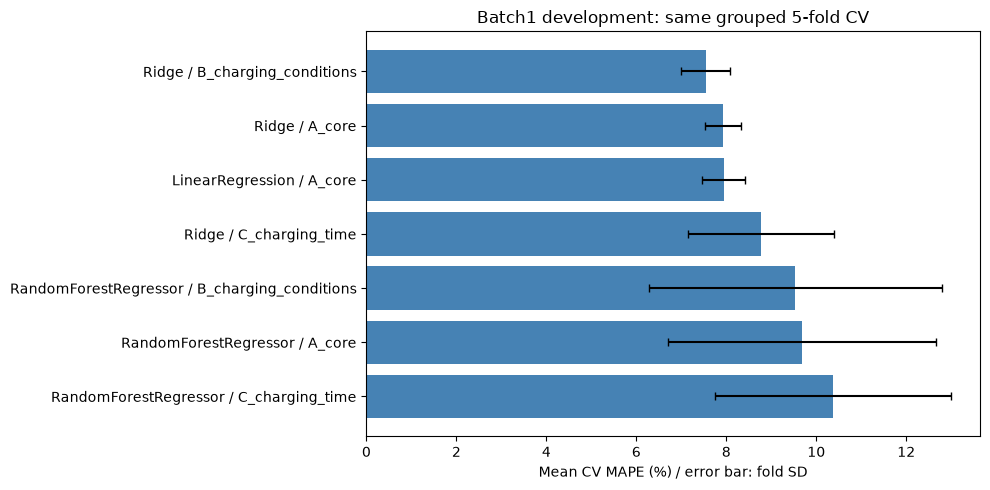

In [6]:
searches, comparison_rows = {}, []
for experiment in experiments:
    model_name, feature_set = experiment['model'], experiment['feature_set']
    experiment_id = f'{model_name} / {feature_set}'
    features = FEATURE_SETS[feature_set]
    search = GridSearchCV(make_estimator(model_name), experiment['grid'], scoring=SCORING,
                          refit='mape', cv=cv_splits, n_jobs=1, error_score='raise', return_train_score=True)
    search.fit(development_df[features], development_df['cycle_life'])
    searches[experiment_id] = search
    index = search.best_index_
    scores = search.cv_results_
    comparison_rows.append({'experiment': experiment_id, 'model': model_name, 'feature_set': feature_set,
                            'n_features': len(features), 'best_parameters': json.dumps(search.best_params_),
                            'cv_mape_percent': -100 * scores['mean_test_mape'][index],
                            'cv_mape_std_pp': 100 * scores['std_test_mape'][index],
                            'cv_mae': -scores['mean_test_mae'][index],
                            'cv_rmse': -scores['mean_test_rmse'][index],
                            'cv_r2': scores['mean_test_r2'][index],
                            'training_mape_percent': -100 * scores['mean_train_mape'][index]})
    print(experiment_id, 'CV MAPE:', round(comparison_rows[-1]['cv_mape_percent'], 3), '%')

candidate_comparison = pd.DataFrame(comparison_rows).sort_values(
    ['cv_mape_percent', 'n_features', 'experiment']).reset_index(drop=True)
selected = candidate_comparison.iloc[0]
selected_search = searches[selected['experiment']]
selected_features = list(FEATURE_SETS[selected['feature_set']])
selected_estimator = clone(selected_search.best_estimator_)
display(candidate_comparison)
print('선택:', selected['experiment'], '/ 설정:', selected_search.best_params_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(candidate_comparison.experiment, candidate_comparison.cv_mape_percent,
        xerr=candidate_comparison.cv_mape_std_pp, color='steelblue', capsize=3)
ax.invert_yaxis()
ax.set(xlabel='Mean CV MAPE (%) / error bar: fold SD', title='Batch1 development: same grouped 5-fold CV')
fig.tight_layout()
plt.show()


## 4. 선택한 모델의 CV 예측과 별도 Hold-out 검증

선택된 설정으로 각 폴드의 미학습 셀을 예측해 OOF(out-of-fold) 예측을 모은다. 제출용 Train 성능은 각 폴드 지표의 단순 평균이며, 전체 OOF를 합쳐 계산한 값과는 다를 수 있다. 예측 그림은 OOF를 사용한다.

개발 셀 전체로 학습한 모델을 Hold-out에 **한 번 적용**한다. Hold-out 결과가 나쁘더라도 이번 실습에서는 이를 보고 설정을 바꾸지 않는다. 모든 지표는 로그가 아닌 원래 Cycle 단위의 실제값·예측값으로 계산한다.


이번 실행에서 Ridge B(alpha=1.0)의 평균 CV MAPE는 7.54%로, Ridge A 7.92%, LinearRegression A 7.94%, Ridge C 8.77%, Random Forest 각 조합 9.53~10.36%보다 낮아 선택됐다. 이는 Batch1 개발 부분의 고정된 분할 결과이며 외부 테스트로 선택한 것이 아니다. 작은 표본이므로 모델의 일반적인 우월성을 확정하지 않는다.

In [7]:
def metrics(y_true, y_pred):
    return {'mape_percent': 100 * mean_absolute_percentage_error(y_true, y_pred),
            'mae': mean_absolute_error(y_true, y_pred),
            'rmse': root_mean_squared_error(y_true, y_pred), 'r2': r2_score(y_true, y_pred)}

def prediction_table(frame, prediction, partition):
    output = frame[['batch', 'cell_id', 'charging_policy', 'cycle_life'] + ALL_FEATURES].copy()
    output['partition'] = partition
    output['prediction'] = np.asarray(prediction)
    output['residual'] = output.prediction - output.cycle_life
    output['ape_percent'] = 100 * output.residual.abs() / output.cycle_life
    return output

oof_prediction = np.full(len(development_df), np.nan)
fold_metrics, assignment_rows = [], []
for fold, (train_index, valid_index) in enumerate(cv_splits, start=1):
    fold_model = clone(selected_estimator)
    fold_model.fit(development_df.iloc[train_index][selected_features], development_df.iloc[train_index].cycle_life)
    prediction = fold_model.predict(development_df.iloc[valid_index][selected_features])
    oof_prediction[valid_index] = prediction
    fold_metrics.append({'fold': fold, **metrics(development_df.iloc[valid_index].cycle_life, prediction)})
    for cell in development_df.iloc[valid_index].to_dict('records'):
        assignment_rows.append({'cell_id': cell['cell_id'], 'charging_policy': cell['charging_policy'], 'protocol_group': cell['protocol_group'],
                                'partition': 'development', 'cv_validation_fold': fold})
for cell in holdout_df.to_dict('records'):
    assignment_rows.append({'cell_id': cell['cell_id'], 'charging_policy': cell['charging_policy'], 'protocol_group': cell['protocol_group'],
                            'partition': 'holdout', 'cv_validation_fold': np.nan})
assert np.isfinite(oof_prediction).all()
fold_metrics_df = pd.DataFrame(fold_metrics)
cv_metrics = fold_metrics_df[['mape_percent', 'mae', 'rmse', 'r2']].mean().to_dict()
assert np.isclose(cv_metrics['mape_percent'], selected['cv_mape_percent'])
development_model = selected_search.best_estimator_  # GridSearchCV가 개발 부분 전체로 refit한 모델
holdout_prediction = development_model.predict(holdout_df[selected_features])
holdout_metrics = metrics(holdout_df.cycle_life, holdout_prediction)
performance_rows = [
    {'partition': 'Train (Batch 1 CV)', 'n': len(development_df), **cv_metrics},
    {'partition': 'Valid (Batch 1 Hold-out)', 'n': len(holdout_df), **holdout_metrics},
]
prediction_parts = [prediction_table(development_df, oof_prediction, 'Train (Batch 1 CV)'),
                    prediction_table(holdout_df, holdout_prediction, 'Valid (Batch 1 Hold-out)')]
display(fold_metrics_df)
display(pd.DataFrame(performance_rows))
display(Markdown(f"선택 모델: **{selected['model']} / {selected['feature_set']}**. CV 평균 MAPE는 **{cv_metrics['mape_percent']:.2f}%**, Hold-out은 **{holdout_metrics['mape_percent']:.2f}%**다."
                 ' Hold-out은 다른 정책 그룹이므로 차이만으로 과적합을 단정하지 않고 분포 차이와 모델 선택의 영향도 고려한다.'))


,fold,mape_percent,mae,rmse,r2
0,1,8.504708,74.645999,85.990700,0.545661
1,2,7.305427,62.785194,73.388767,0.801725
2,3,7.263697,70.751859,88.688075,0.842875
3,4,7.721887,57.871250,89.303948,0.525707
4,5,6.910142,51.893773,77.312296,0.512536


,partition,n,mape_percent,mae,rmse,r2
0,Train (Batch 1 CV),35,7.541172,63.589615,82.936757,0.645701
1,Valid (Batch 1 Hold-out),11,13.492500,136.795613,196.046233,-0.063386


선택 모델: **Ridge / B_charging_conditions**. CV 평균 MAPE는 **7.54%**, Hold-out은 **13.49%**다. Hold-out은 다른 정책 그룹이므로 차이만으로 과적합을 단정하지 않고 분포 차이와 모델 선택의 영향도 고려한다.

## 5. 설정을 고정하고 Batch1 전체로 최종 학습

선택한 모델·피처·하이퍼파라미터를 여기서 고정한다. 같은 설정으로 Batch1 전체 46셀을 학습하고, 이후 Batch2·3은 이 하나의 최종 모델로만 예측한다.

Hold-out 평가 모델은 개발 셀만, 외부 테스트 모델은 Batch1 전체로 학습했으므로 학습 셀 수가 다르다. Gap은 일반화의 단서지만 동일한 학습 완료 모델의 성능 차이는 아니다.


In [8]:
frozen_configuration = {'model': selected['model'], 'feature_set': selected['feature_set'],
                        'features': selected_features, 'parameters': selected_search.best_params_,
                        'seed': SEED, 'selection_metric': 'mean grouped CV MAPE'}
frozen_configuration_text = json.dumps(frozen_configuration, sort_keys=True)
final_model = clone(selected_estimator)
final_model.fit(batch1_df[selected_features], batch1_df.cycle_life)
print('최종 학습 셀:', len(batch1_df))
display(pd.Series(frozen_configuration, name='fixed_setting').to_frame())


최종 학습 셀: 46


,fixed_setting
model,Ridge
feature_set,B_charging_conditions
features,"[log10_delta_q_var, c_rate_1, switch_soc]"
parameters,{'regressor__model__alpha': 1.0}
seed,42
selection_metric,mean grouped CV MAPE


## 6. Batch2 최종 평가와 Batch3 추가 검증

이제 외부 배치에 동일한 피처 공식을 적용한다. 최종 모델·피처·처리 기준은 바꾸지 않는다. 배치당 입력 적격 셀을 한 번 예측하고, 그 예측을 재사용해 지표·그래프·오류 분석을 작성한다.

결측 수명은 평가에서 제외하고, 입력이 확보된 셀의 예측만 별도 저장한다. 수명이 짧거나 오차가 크다는 이유로 테스트 셀을 제거하지 않는다. 초기 입력이 없는 경우의 제외와 라벨 결측으로 채점하지 못하는 경우를 구분한다.


In [9]:
external_features, unlabeled_parts = [], []
for batch_name in ['Batch 2', 'Batch 3']:
    metadata, raw_inputs = load_raw_batch(BATCH_FILES[batch_name], batch_name)
    features = make_features(metadata, raw_inputs)
    external_features.append(features)
    quality_rows.append(quality_summary(metadata, features))
    eligible = features.loc[(features.n_initial_cycles == 100) & (features.n_delta_points >= 10)].copy()
    all_prediction = final_model.predict(eligible[selected_features])
    table = prediction_table(eligible, all_prediction, f'Test ({batch_name})')
    scored_mask = np.isfinite(table.cycle_life) & (table.cycle_life > 0)
    scored = table.loc[scored_mask].copy()
    unlabeled = table.loc[~scored_mask].copy()
    prediction_parts.append(scored)
    unlabeled_parts.append(unlabeled)
    performance_rows.append({'partition': f'Test ({batch_name})', 'n': len(scored),
                             **metrics(scored.cycle_life, scored.prediction)})
assert json.dumps(frozen_configuration, sort_keys=True) == frozen_configuration_text
performance_df = pd.DataFrame(performance_rows)
predictions_df = pd.concat(prediction_parts, ignore_index=True)
unlabeled_predictions_df = pd.concat(unlabeled_parts, ignore_index=True)
data_quality_df = pd.DataFrame(quality_rows)
display(data_quality_df)
display(performance_df)
print('수명 결측 등으로 채점하지 않은 참고 예측:', len(unlabeled_predictions_df), '셀')


,batch,raw_cells,missing_target,nonpositive_target,input_ineligible,scored_cells,unlabeled_prediction_cells
0,Batch 1,46,0,0,0,46,0
1,Batch 2,47,8,0,0,39,8
2,Batch 3,46,2,0,0,44,2


,partition,n,mape_percent,mae,rmse,r2
0,Train (Batch 1 CV),35,7.541172,63.589615,82.936757,0.645701
1,Valid (Batch 1 Hold-out),11,13.492500,136.795613,196.046233,-0.063386
2,Test (Batch 2),39,50.102975,234.983221,264.818107,-0.457746
3,Test (Batch 3),44,17.536263,200.414508,300.933476,0.059353


수명 결측 등으로 채점하지 않은 참고 예측: 10 셀


## 7. 원논문 성능과 비교

In [10]:
score = performance_df.set_index('partition')['mape_percent']
cv_score = score['Train (Batch 1 CV)']
valid_score = score['Valid (Batch 1 Hold-out)']
test2_score, test3_score = score['Test (Batch 2)'], score['Test (Batch 3)']
report_rows = [
    ('Train (Batch 1 CV)', cv_score, '%', '개발 셀의 5개 검증 폴드 평균'),
    ('Valid (Batch 1 Hold-out)', valid_score, '%', '개발 부분에서 학습한 고정 설정 모델'),
    ('Test (Batch 2)', test2_score, '%', 'Batch1 전체로 재학습한 최종 모델'),
    ('Gap (Train-Valid)', valid_score - cv_score, 'pp', 'Valid−CV; (+) 오차 증가'),
    ('Gap (Valid-Test)', test2_score - valid_score, 'pp', 'Batch2−Valid; (+) 오차 증가'),
    ('Gap (Target-Test)', test2_score - PAPER_MAPE, 'pp', 'Batch2−9.1; (+) 과제 목표 미달'),
    ('Test (Batch 3)', test3_score, '%', '동일 최종 모델의 추가 평가'),
    ('Gap (Batch2-Batch3)', test3_score - test2_score, 'pp', 'Batch3−Batch2; (+) Batch3 오차 증가'),
    ('Gap (Target-Test, Batch 3)', test3_score - PAPER_MAPE, 'pp', 'Batch3−9.1; 참고 비교'),
]
performance_report_df = pd.DataFrame(report_rows, columns=['구분', 'MAPE / Gap', '단위', '비고'])
display(performance_report_df.round({'MAPE / Gap': 3}))
display(Markdown(f"Batch2 MAPE는 **{test2_score:.2f}%**, 과제 목표와의 차이는 **{test2_score - PAPER_MAPE:+.2f}pp**이다. "
                 f"Batch3 MAPE는 **{test3_score:.2f}%**로 Batch2 대비 **{test3_score - test2_score:+.2f}pp** 차이가 난다. "))


,구분,MAPE / Gap,단위,비고
0,Train (Batch 1 CV),7.541,%,개발 셀의 5개 검증 폴드 평균
1,Valid (Batch 1 Hold-out),13.493,%,개발 부분에서 학습한 고정 설정 모델
2,Test (Batch 2),50.103,%,Batch1 전체로 재학습한 최종 모델
3,Gap (Train-Valid),5.951,pp,Valid−CV; (+) 오차 증가
4,Gap (Valid-Test),36.610,pp,Batch2−Valid; (+) 오차 증가
5,Gap (Target-Test),41.003,pp,Batch2−9.1; (+) 과제 목표 미달
6,Test (Batch 3),17.536,%,동일 최종 모델의 추가 평가
7,Gap (Batch2-Batch3),-32.567,pp,Batch3−Batch2; (+) Batch3 오차 증가
8,"Gap (Target-Test, Batch 3)",8.436,pp,Batch3−9.1; 참고 비교


Batch2 MAPE는 **50.10%**, 과제 목표와의 차이는 **+41.00pp**이다. Batch3 MAPE는 **17.54%**로 Batch2 대비 **-32.57pp** 차이가 난다. 

## 8. 실제값·예측값과 잔차 확인

위에서 저장한 예측을 사용한다. 대각선보다 위에 있으면 수명 과대 예측, 아래에 있으면 과소 예측이다. 잔차는 `예측−실제`다. 개발 부분은 OOF 예측, Hold-out은 개발 모델, Batch2·3은 최종 모델의 예측이므로 구분해서 본다.


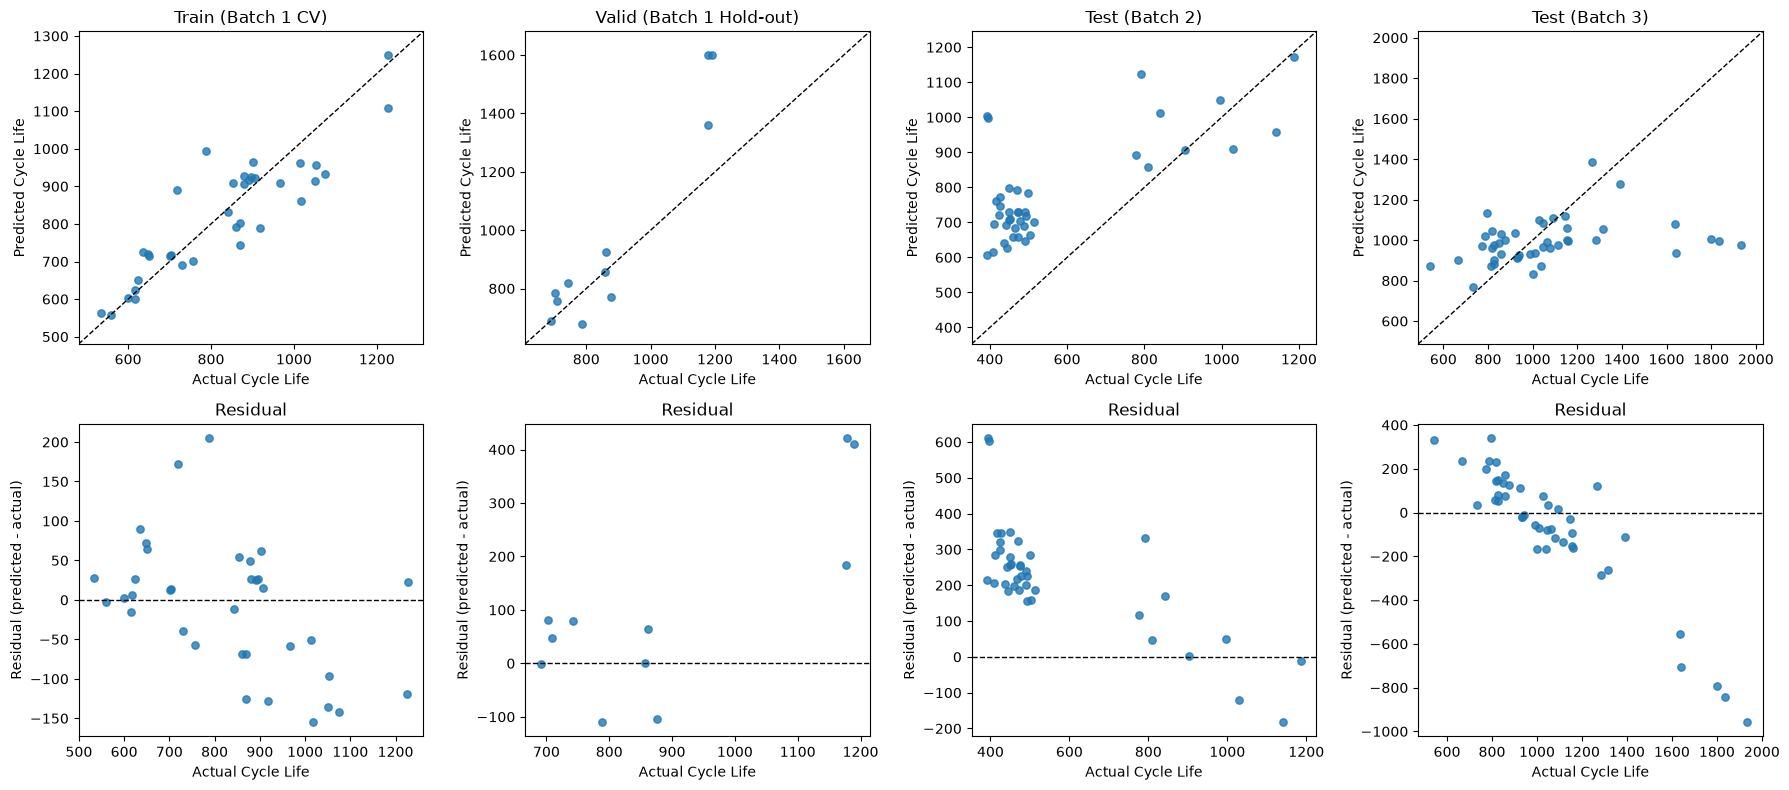

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for column, (partition, group) in enumerate(predictions_df.groupby('partition', sort=False)):
    ax = axes[0, column]
    ax.scatter(group.cycle_life, group.prediction, s=28, alpha=0.8)
    lower = min(group.cycle_life.min(), group.prediction.min()) * 0.9
    upper = max(group.cycle_life.max(), group.prediction.max()) * 1.05
    ax.plot([lower, upper], [lower, upper], 'k--', linewidth=1)
    ax.set(xlim=(lower, upper), ylim=(lower, upper), xlabel='Actual Cycle Life', ylabel='Predicted Cycle Life', title=partition)
    axes[1, column].scatter(group.cycle_life, group.residual, s=28, alpha=0.8)
    axes[1, column].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[1, column].set(xlabel='Actual Cycle Life', ylabel='Residual (predicted - actual)', title='Residual')
fig.tight_layout()
plt.show()


## 9. 오류 분석

외부 배치의 큰 오차 셀과 잔차 방향을 확인한다. Batch1의 입력 범위·수명 범위를 벗어난 셀 수도 확인한다. 범위 밖이라는 이유로 셀을 제외하지 않는다. 이 진단은 이미 저장한 최종 예측을 해석하는 데만 사용한다.

분포 차이는 일반화 저하의 설명 후보지만 인과관계의 증거는 아니다. 특히 충전 정책별 표본 수가 작아 특정 정책이 오차의 유일한 원인이라고 단정할 수 없다.


In [12]:
range_rows, error_summary_rows = [], []
for batch_name in ['Batch 2', 'Batch 3']:
    group = predictions_df.loc[predictions_df.batch == batch_name]
    error_summary_rows.append({'batch': batch_name, 'n': len(group),
                               'overprediction_cells': int((group.residual > 0).sum()),
                               'underprediction_cells': int((group.residual < 0).sum()),
                               'mean_residual_cycle': group.residual.mean()})
    print(batch_name, ': 상대오차가 큰 5개 셀')
    display(group.nlargest(5, 'ape_percent')[['cell_id', 'charging_policy', 'cycle_life', 'prediction', 'residual', 'ape_percent']].round(2))
    for column in selected_features + ['cycle_life']:
        low, high = batch1_df[column].min(), batch1_df[column].max()
        range_rows.append({'batch': batch_name, 'variable': column, 'train_min': low, 'train_max': high,
                           'test_min': group[column].min(), 'test_max': group[column].max(),
                           'below_train_range': int((group[column] < low).sum()),
                           'above_train_range': int((group[column] > high).sum())})
range_diagnostics_df = pd.DataFrame(range_rows)
error_summary_df = pd.DataFrame(error_summary_rows)
display(error_summary_df.round(2))
display(range_diagnostics_df.round(4))

batch2_error = error_summary_df.set_index('batch').loc['Batch 2']
batch3_error = error_summary_df.set_index('batch').loc['Batch 3']
target_range = range_diagnostics_df.loc[range_diagnostics_df.variable == 'cycle_life'].set_index('batch')
display(Markdown(
    f"**관찰 결과**: Batch2는 {int(batch2_error.overprediction_cells)}/{int(batch2_error.n)}셀에서 과대 예측했고, "
    f"평균 잔차는 {batch2_error.mean_residual_cycle:+.2f} Cycle이다. "
    f"Batch2의 {int(target_range.loc['Batch 2', 'below_train_range'])}셀은 Batch1의 최소 수명보다 짧다. "
    f"Batch3에는 Batch1의 최대 수명보다 긴 셀이 {int(target_range.loc['Batch 3', 'above_train_range'])}개 있으며, "
    f"평균 잔차는 {batch3_error.mean_residual_cycle:+.2f} Cycle이다. "
    '\n\n**해석**: 작은 학습 표본, 미관측 충전 조건과 수명·입력 분포 차이가 오차의 설명 후보다. '
    '단수명 셀의 상대오차가 MAPE를 키울 수 있으므로 Cycle 단위 오차도 함께 봐야 한다. '
    '이 결과만으로 물리적 원인이나 단일 원인을 확정하지 않는다.'))


Batch 2 : 상대오차가 큰 5개 셀


,cell_id,charging_policy,cycle_life,prediction,residual,ape_percent
52,Batch2_cell_006,3.6C(9%)-5C,393.0,1004.06,611.06,155.49
61,Batch2_cell_015,3.6C(9%)-5C,396.0,998.41,602.41,152.12
51,Batch2_cell_005,3.6C(30%)-6C,416.0,760.89,344.89,82.91
60,Batch2_cell_014,3.6C(30%)-6C,426.0,771.21,345.21,81.04
64,Batch2_cell_018,5.2C(50%)-4.25C,449.0,799.05,350.05,77.96


Batch 3 : 상대오차가 큰 5개 셀


,cell_id,charging_policy,cycle_life,prediction,residual,ape_percent
112,Batch3_cell_028,3.7C(31%)-5.9C-newstructure,541.0,874.49,333.49,61.64
121,Batch3_cell_038,5C(67%)-4C-newstructure,1935.0,976.59,-958.41,49.53
92,Batch3_cell_007,4.8C(80%)-4.8C-newstructure,1836.0,993.36,-842.64,45.90
128,Batch3_cell_045,4.8C(80%)-4.8C-newstructure,1801.0,1006.63,-794.37,44.11
125,Batch3_cell_042,4.8C(80%)-4.8C-newstructure,1642.0,936.46,-705.54,42.97


,batch,n,overprediction_cells,underprediction_cells,mean_residual_cycle
0,Batch 2,39,36,3,218.77
1,Batch 3,44,21,23,-66.36


,batch,variable,train_min,train_max,test_min,test_max,below_train_range,above_train_range
0,Batch 2,log10_delta_q_var,-5.0144,-3.3502,-4.4484,-3.0858,0,11
1,Batch 2,c_rate_1,3.6000,8.0000,3.6000,6.0000,0,0
2,Batch 2,switch_soc,15.0000,80.0000,9.0000,80.0000,2,0
3,Batch 2,cycle_life,534.0000,1227.0000,392.0000,1186.0000,30,0
4,Batch 3,log10_delta_q_var,-5.0144,-3.3502,-5.1016,-3.4516,1,0
5,Batch 3,c_rate_1,3.6000,8.0000,3.7000,5.9000,0,0
6,Batch 3,switch_soc,15.0000,80.0000,15.0000,80.0000,0,0
7,Batch 3,cycle_life,534.0000,1227.0000,541.0000,1935.0000,0,9


**관찰 결과**: Batch2는 36/39셀에서 과대 예측했고, 평균 잔차는 +218.77 Cycle이다. Batch2의 30셀은 Batch1의 최소 수명보다 짧다. Batch3에는 Batch1의 최대 수명보다 긴 셀이 9개 있으며, 평균 잔차는 -66.36 Cycle이다. 

**해석**: 작은 학습 표본, 미관측 충전 조건과 수명·입력 분포 차이가 오차의 설명 후보다. 단수명 셀의 상대오차가 MAPE를 키울 수 있으므로 Cycle 단위 오차도 함께 봐야 한다. 이 결과만으로 물리적 원인이나 단일 원인을 확정하지 않는다.

## 10. ESS 관점의 해석과 한계

초기 100사이클 이후 셀 수명 스크리닝이나 추가 시험 우선순위 결정에 활용할 가능성은 있지만, 현재 성능으로 안전 관련 운영 결정을 자동화하기에는 부족하다. 수명 과대 예측은 교체 지연, 과소 예측은 불필요한 교체 비용으로 이어질 수 있다.

- 이 모델은 실험 셀의 총 Cycle Life 회귀다. 실사용 BESS의 RUL, 달력 열화, 모듈 수준 열화·운전 조건을 모두 설명하지 않는다.
- Batch1은 46셀로 작다. 정책 그룹 검증은 미관측 정책에 대한 점검이지만 Hold-out 11셀의 추정도 불안정할 수 있다.
- 최종 선택에 사용한 CV는 선택 편향이 있으며, Hold-out도 독립적인 배치 간 검증을 대신하지 않는다.
- DAY1에서 외부 라벨을 관찰했다. 엄밀한 최종 일반화 확인에는 추가 미관측 데이터가 필요하다.
- 과제 목표 9.1%는 비교 기준이다. 원논문의 셀 정제·연속 실험 처리·피처 계산·분할을 완전히 재현하지 않았다.
- 실제 운영 Live Test는 수행하지 않았다. 모델을 개선할 때는 새 개발/검증 계획과 별도 최종 테스트셋을 확보해야 한다.

운영 적용 전에는 입력 범위·결측률·전압축 품질을 감시하고 Data Drift와 관측 가능한 실제 수명의 Model Drift를 추적한다. 예를 들어 월별 입력 분포 점검, 신규 수명 라벨 확보 시 오차 점검, 사전에 합의한 드리프트·오차 기준 초과 시 재학습 검토를 계획할 수 있다. 임계값과 주기는 실제 운영 비용·데이터 주기에 맞춰 별도로 정해야 한다. 이번 코드에 운영 배포·재학습 자동화는 포함하지 않는다.


## 11. 최소 결과 저장

과제 결과로 필요한 성능표만 `results/model_performance.csv`에 저장한다. 후보 비교표, 셀별 예측값, 그래프, 분할 목록과 모델 파일은 노트북 출력에서 확인할 수 있으므로 별도 파일로 저장하지 않는다. 노트북을 다시 실행하면 같은 성능표 한 개만 갱신한다.

In [13]:
metric_notes = {
    'Train (Batch 1 CV)': '개발 셀의 5개 검증 폴드 평균',
    'Valid (Batch 1 Hold-out)': '개발 부분에서 학습한 고정 설정 모델',
    'Test (Batch 2)': 'Batch1 전체로 재학습한 최종 모델',
    'Test (Batch 3)': '동일 최종 모델의 추가 평가',
}
performance_lookup = performance_df.set_index('partition')
result_rows = []
for row in performance_report_df.to_dict('records'):
    name = row['구분']
    metric = performance_lookup.loc[name] if name in performance_lookup.index else None
    result_rows.append({
        '구분': name, 'n': metric['n'] if metric is not None else np.nan,
        'MAPE_or_Gap': row['MAPE / Gap'], '단위': row['단위'],
        'MAE_Cycle': metric['mae'] if metric is not None else np.nan,
        'RMSE_Cycle': metric['rmse'] if metric is not None else np.nan,
        'R2': metric['r2'] if metric is not None else np.nan,
        '비고': metric_notes.get(name, row['비고']),
    })
model_performance_export_df = pd.DataFrame(result_rows)
result_path = RESULTS_DIR / 'model_performance.csv'
model_performance_export_df.to_csv(result_path, index=False, encoding='utf-8-sig')
display(model_performance_export_df.round(3))
print('저장 완료:', result_path)
print('그 외 중간 결과와 모델 파일은 저장하지 않았습니다.')

,구분,n,MAPE_or_Gap,단위,MAE_Cycle,RMSE_Cycle,R2,비고
0,Train (Batch 1 CV),35.0,7.541,%,63.590,82.937,0.646,개발 셀의 5개 검증 폴드 평균
1,Valid (Batch 1 Hold-out),11.0,13.493,%,136.796,196.046,-0.063,개발 부분에서 학습한 고정 설정 모델
2,Test (Batch 2),39.0,50.103,%,234.983,264.818,-0.458,Batch1 전체로 재학습한 최종 모델
3,Gap (Train-Valid),NaN,5.951,pp,NaN,NaN,NaN,Valid−CV; (+) 오차 증가
4,Gap (Valid-Test),NaN,36.610,pp,NaN,NaN,NaN,Batch2−Valid; (+) 오차 증가
5,Gap (Target-Test),NaN,41.003,pp,NaN,NaN,NaN,Batch2−9.1; (+) 과제 목표 미달
6,Test (Batch 3),44.0,17.536,%,200.415,300.933,0.059,동일 최종 모델의 추가 평가
7,Gap (Batch2-Batch3),NaN,-32.567,pp,NaN,NaN,NaN,Batch3−Batch2; (+) Batch3 오차 증가
8,"Gap (Target-Test, Batch 3)",NaN,8.436,pp,NaN,NaN,NaN,Batch3−9.1; 참고 비교


저장 완료: /Users/jjy/ds-mini-project/results/model_performance.csv
그 외 중간 결과와 모델 파일은 저장하지 않았습니다.


## 12. 최종 모델·성능·해석

위의 모델 선택과 외부 평가 결과를 한곳에 정리한다. 아래 값은 앞에서 계산한 결과를 그대로 사용했으며, 테스트 결과를 보고 모델을 다시 선택하거나 조정하지 않았다.

### 최종 선택 모델

- **모델:** Ridge Regression (`alpha=1.0`)
- **피처 조합:** B_charging_conditions
- **사용 피처:** `log10_delta_q_var`, `c_rate_1`, `switch_soc`
- **선택 기준:** Batch1 개발 부분의 충전 정책 그룹 5-fold CV 평균 MAPE 최소

### 최종 성능

| 구분 | 셀 수 | MAPE | MAE (Cycle) | RMSE (Cycle) | R² |
|---|---:|---:|---:|---:|---:|
| Batch1 CV | 35 | 7.54% | 63.59 | 82.94 | 0.646 |
| Batch1 Hold-out | 11 | 13.49% | 136.80 | 196.05 | -0.063 |
| Batch2 Test | 39 | 50.10% | 234.98 | 264.82 | -0.458 |
| Batch3 Test | 44 | 17.54% | 200.41 | 300.93 | 0.059 |

### 결과 해석

Ridge B는 Batch1 내부 CV에서 평균 MAPE가 가장 낮아 최종 모델로 선택됐다. 그러나 Hold-out MAPE가 13.49%로 상승하여 Batch1 내부에서도 학습에서 보지 않은 충전 정책에 대한 성능 저하가 확인됐다.

Batch2 MAPE는 **50.10%**로 과제 목표 9.1%보다 **41.00%p 높다**. Batch2 39셀 중 36셀을 과대 예측했으며, 30셀의 실제 수명이 Batch1 학습 수명의 최솟값보다 짧았다. 따라서 Batch1에서 학습한 피처와 수명의 관계가 Batch2의 다수 단수명 셀로 충분히 일반화되지 않았다고 해석한다. 이는 MAPE 계산 오류가 아니라 현재 모델의 배치 간 일반화 한계다.

Batch3 MAPE는 **17.54%**로 Batch2보다 낮지만 과제 목표보다는 **8.44%p 높다**. Batch3에는 Batch1의 최대 수명을 넘는 셀이 9개 있어 장수명 영역을 과소 예측하는 문제도 확인됐다.

따라서 이 모델은 Batch1 내부 관계를 설명하는 초기 모델로는 의미가 있지만, 현재 상태로 실제 ESS의 교체·안전 의사결정에 적용하기에는 외부 일반화 성능이 부족하다. 새로운 미관측 데이터와 배치 차이를 반영한 피처 및 검증 설계가 추가로 필요하다.